In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load best model and data
xgb_model = joblib.load('../models/xgb_model.pkl')

X_test = pd.read_csv('../data/X_test.csv')
y_test = pd.read_csv('../data/y_test.csv').squeeze()

print("X_test shape:", X_test.shape)

X_test shape: (280, 20)


In [4]:
# Initialize SHAP explainer
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (280, 20)


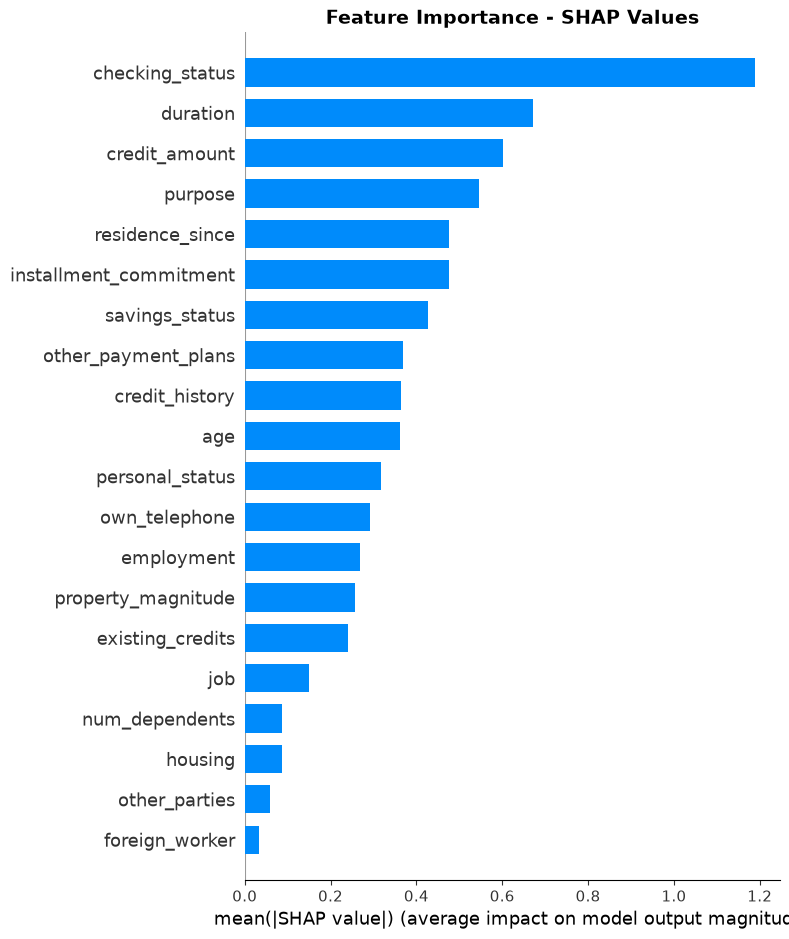

In [5]:
# SHAP Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, 
                  plot_type="bar",
                  show=False)

plt.title('Feature Importance - SHAP Values', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

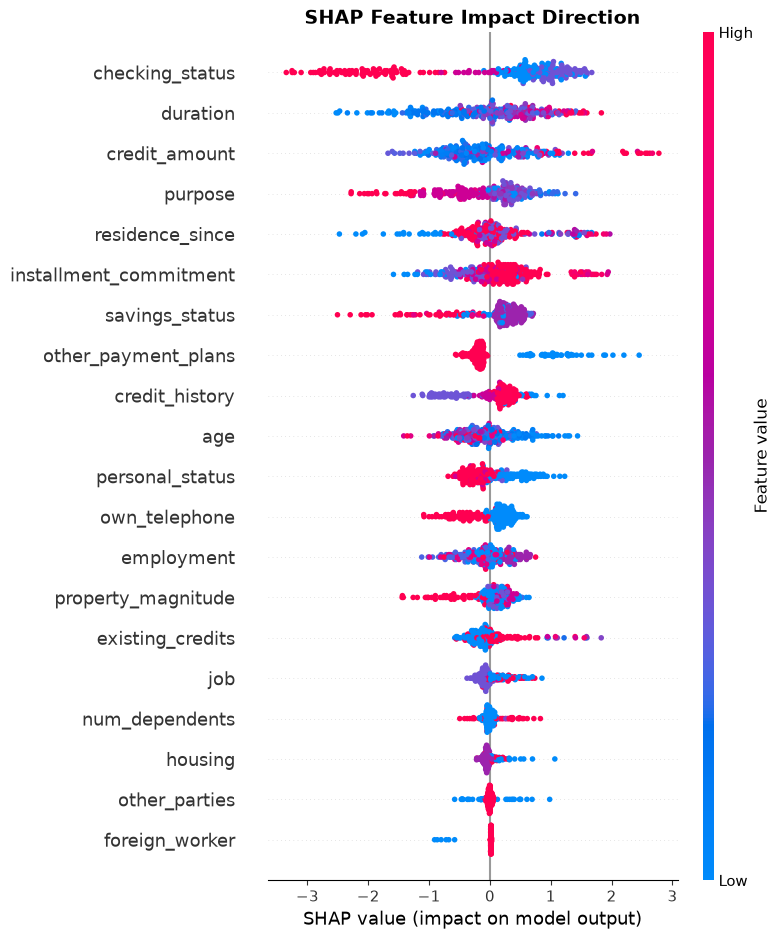

In [6]:
# SHAP Dot Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test,
                  plot_type="dot",
                  show=False)

plt.title('SHAP Feature Impact Direction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/shap_dot_plot.png', dpi=150, bbox_inches='tight')
plt.show()

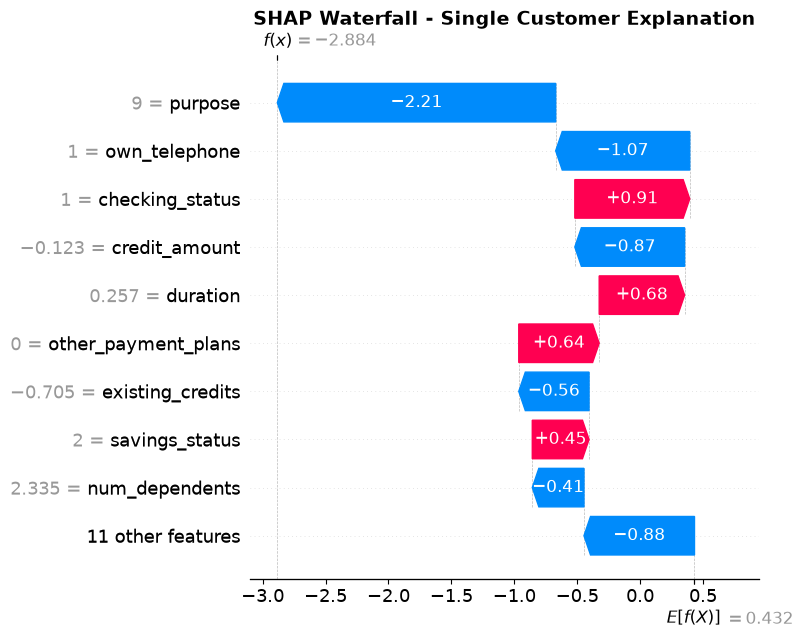

In [7]:
# SHAP Waterfall plot for single prediction
explainer2 = shap.Explainer(xgb_model, X_test)
shap_values2 = explainer2(X_test)

# Plot for first customer
plt.figure(figsize=(12, 6))
shap.plots.waterfall(shap_values2[0], show=False)

plt.title('SHAP Waterfall - Single Customer Explanation', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 1000x600 with 0 Axes>

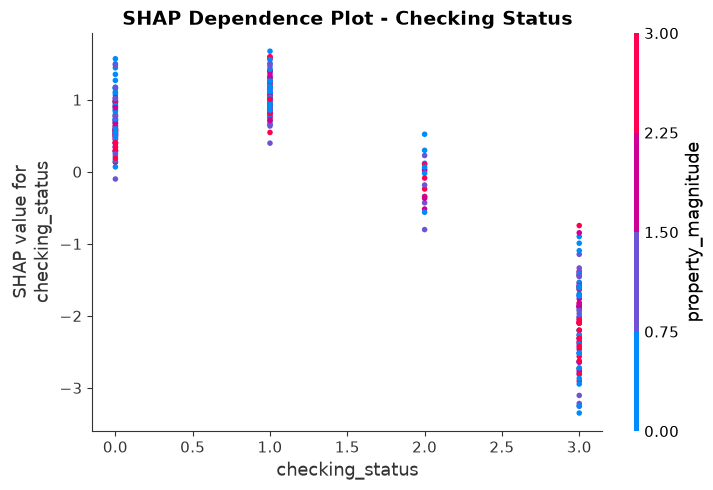

In [8]:
# SHAP Dependence plot for top feature
plt.figure(figsize=(10, 6))
shap.dependence_plot('checking_status', 
                      shap_values, 
                      X_test,
                      show=False)

plt.title('SHAP Dependence Plot - Checking Status', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()